# Complementary filter

Conceptually, sensor fusion consists on estimating a magnitude leveraging data from different sensors. In this case, the magnitudes of interest are roll and pitch, which will be later used to remove gravity from linear acceleration by trasforming the g vector to the device's reference frame and substracting it. 

The complementary filter is a simple way to do this, based on different characteristics of the sensors:

* Gyroscope: good short-term stability, but drifts in the long term.
* Accelerometer: good long-term stability, but noisy in the short term.

On continuous time the idea would be to apply a low-pass effect on angle computed from accelerometer data and a high-pass effect on the integrated gyroscope data. On discrete time, this can be implemented with the following formula:

$$
\theta_t = \alpha (\theta_{t-1} + \omega_{t} \cdot \Delta t) + (1 - \alpha) \theta_{acc, t}
$$

Where $0 < \alpha \leq 1$ is a tuning parameter, and: $\alpha = \frac{\tau}{\tau + \Delta t}$, where $\tau$ is the time constant of the filter and $\Delta t$ is the sampling period.

In 3D space, considering the FLU (forwards, left, up) system of coordinates shown in the figure below:

<img src="../../docs/misc/roll-pitch-yaw.webp" alt="Coordinate system" width="250" height="250">

For the device at rest and with no other forces acting on it aside from gravity: 

  $$
    a_{x} = - g \cdot sin\ \theta_{acc, pitch}
  $$

  $$
  a_{y} = g \cdot sin\ \theta_{acc, roll} \cdot cos\ \theta_{acc, pitch}
  $$
  
  $$
  a_{z} = g \cdot cos\ \theta_{acc, roll} \cdot cos\ \theta_{acc, pitch}
  $$

Angles from the accelerometer can be computed with the following formulas:

  $$
    \theta_{acc, roll} = arctan(\frac{a_{y}}{a_{z}})
  $$

  $$
    \theta_{acc, pitch} = arctan(\frac{-a_{x}}{\sqrt{a_{y}^2 + a_{z}^2}})
  $$

  Note: within this notebook, use *atan2* instead of *atan* to compute the angles, since it preserves the cuadrant of the angle when both arguments carry a sign.

Notice that $\theta_{acc, yaw}$ can't be computed from the accelerometer data, since the rotation around the gravity vector is unobservable from acceleration.  Another point of reference, such as a magnetometer, would be needed to compute this angle. As a consequence, the complementary filter can only be applied to roll and pitch angles, while the yaw angle can only be computed from the gyroscope data. However, since common calisthenics movements happen mostly on the sagital plane and a minor set on the frontal plane of the human body, the XY plane can be oriented to correspond with the plane of least importance, i.e. the transverse plane. As a reference, the following figure shows the three planes of movement of the human body: 

<img src="../../docs/misc/planes-of-motion-human-body.webp" alt="Coordinate system" width="400" height="300">
 
Since the mounted sensor on the first prototype is not actually in the coordinate system shown in the figure above, but with the +x axis pointing to the right, +y axis pointing down, and +z axis pointing forwards, the frame has to be transformed through software with a linear transformation:

$$
\boldsymbol{a}_{software}
=
\begin{bmatrix}
0 & 0 & 1 \\
-1 & 0 & 0 \\
0 & -1 & 0
\end{bmatrix}
\cdot
\boldsymbol{a}_{hardware}
$$

$$
\boldsymbol{\omega}_{software}
=
\begin{bmatrix}
0 & 0 & 1 \\
-1 & 0 & 0 \\
0 & -1 & 0
\end{bmatrix}
\cdot
\boldsymbol{\omega}_{hardware}
$$
or more simply,
$$
\boldsymbol{a}_{x, software} = \boldsymbol{a}_{z, hardware} \newline
\boldsymbol{a}_{y, software} = -\boldsymbol{a}_{x, hardware} \newline
\boldsymbol{a}_{z, software} = -\boldsymbol{a}_{y, hardware}
$$
$$
\boldsymbol{\omega}_{roll, software} = \boldsymbol{\omega}_{yaw, hardware} \newline
\boldsymbol{\omega}_{pitch, software} = -\boldsymbol{\omega}_{roll, hardware} \newline
\boldsymbol{\omega}_{yaw, software} = -\boldsymbol{\omega}_{pitch, hardware}



$$




Additionally, the formulas assume that gravity is the only force acting on the device, but that is not the case in this application. A possible solution could involve changing alpha to favor the gyroscope data more heavily when the device is in motion, and weigh the accelerometer more when the device is relatively stationary. A simple (but not perfect) way to detect motion is to check that: $ | ||\mathbf{a}|| - g | > tol $, where *tol* is a tolerance value that can be tuned.  

Sources:

* ["The balance filter" by Shane Colton](../../docs/misc/Motion%20filters.pdf)

* ["Using an Accelerometer for inclination sensing" application note by Christopher Fisher](../../docs/misc/Accelerometer%20inclination.pdf)

* [Drone Control and the Complementary Filter by Brian Douglas](https://www.youtube.com/watch?v=whSw42XddsU)


## Setup

In [33]:
from signal_utils import IMUSampleReader, IMUSampleTimeSeriesPlotter
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats
from statistics import fmean, pstdev

# CAPTURE_PATH = "../exercise-reception/capture-apr-28-2026/pull-ups-1.csv"
# CAPTURE_PATH = "../1-calibration/output/positive-z-up-calibrated.csv"

CAPTURE_PATH = "./capture/rotation-x-hw.csv"
# CAPTURE_PATH = "./capture/rotation-y-hw.csv"
# CAPTURE_PATH = "./capture/rotation-z-hw.csv"

reader = IMUSampleReader()
samples = reader.read(CAPTURE_PATH)

rawSamplestimeSeriesPlotter = IMUSampleTimeSeriesPlotter()

## Transform frame

In [34]:
axHw = np.array(samples["a"]["x"])
ayHw = np.array(samples["a"]["y"])
azHw = np.array(samples["a"]["z"])
samples["a"]["x"] = azHw
samples["a"]["y"] = -1 * axHw
samples["a"]["z"] = -1 * ayHw

rollHw = np.array(samples["w"]["roll"])
pitchHw = np.array(samples["w"]["pitch"])
yawHw = np.array(samples["w"]["yaw"])
samples["w"]["roll"] = yawHw
samples["w"]["pitch"] = -1 * rollHw
samples["w"]["yaw"] = -1 * pitchHw

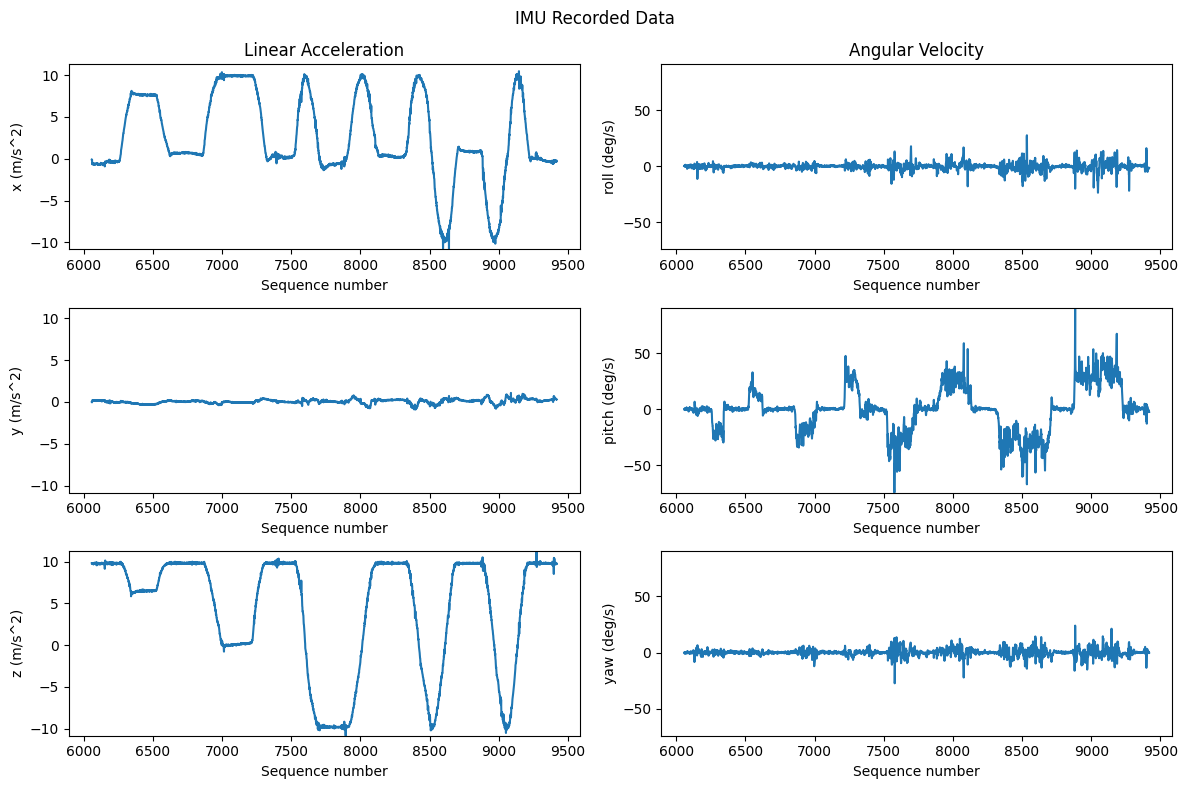

In [35]:
rawSamplestimeSeriesPlotter.plot(samples)

## Inverse tangent behavior

Situate yourself on the plane. `math.atan2(y, x)` (or its vector form, `np.atan(y, x)`) returns the angle in the interval [-π, π] between the positive X‑axis and the point (x,y) (i.e. the angle of the vector from the origin to (x, y)). It differs from the regular `math.atan(y/x)` because it uses the signs of both arguments to determine the correct quadrant.

$$
\operatorname{atan2}(y,x)=\begin{cases}
\arctan\!\left(\dfrac{y}{x}\right) & x>0\\[6pt]
\arctan\!\left(\dfrac{y}{x}\right)+\pi & x<0,\ y\ge 0\\[6pt]
\arctan\!\left(\dfrac{y}{x}\right)-\pi & x<0,\ y<0\\[6pt]
+\dfrac{\pi}{2} & x=0,\ y>0\\[6pt]
-\dfrac{\pi}{2} & x=0,\ y<0\\[6pt]
0 & x=0,\ y=0\\[6pt]
\end{cases}
$$

Examples:
- `atan2(1,1) = π/4`  
- `atan2(1,-1) = 3π/4`  
- `atan2(-1,-1) = -3π/4`  
- `atan2(-1,1) = -π/4`  
- `atan2(0,-1) = π`

The function is vulnerable to rapid oscillations when the angle moves close to the negative x axis (i.e. y close to 0 by excess or defect). To fix this, there are many options, from cheaper/simpler to more complex/expensive:

* Use a tolerance band within which y = 0 is assigned. Chosen option, at least for now.

* Use hysterisis (small non-linearity): the output is given by previous inputs and the direction of the change. If y is positive and greater than a tolerance, switch to positive. If it's negative and less than a tolerance, switch to negative. Otherwise use a previous state.

* Unwrap the angle so that it evolves continuously over time. Not necessary for this application.

* Sin/cos filtering: compute the angle, then remap it to coordinates with cosine and sine functions for the x and y axes, respectively. Then apply an exponential smoothing effect on both series. Lastly recompute the angle with the inverse tangent function. 

Notice that if both x and y are close to 0, then the angle itself is poorly defined. 

Special function evaluations:

In [36]:
print(f"atan2(1, 0) = {math.atan2(1, 0)}")
print(f"atan2(-1, 0) = {math.atan2(-1, 0)}")
print(f"atan2(0, 0) = {math.atan2(0, 0)}")
print(f"atan2(inf, 1) = {math.atan2(float('inf'), 1)}")
print(f"atan2(-inf, 1) = {math.atan2(float('-inf'), 1)}")
print(f"atan2(inf, -1) = {math.atan2(float('inf'), -1)}")
print(f"atan2(-inf, -1) = {math.atan2(float('-inf'), -1)}")
print(f"atan2(1, inf) = {math.atan2(1, float('inf'))}")
print(f"atan2(1, -inf) = {math.atan2(1, float('-inf'))}")
print(f"atan2(-1, inf) = {math.atan2(-1, float('inf'))}")
print(f"atan2(-1, -inf) = {math.atan2(-1, float('-inf'))}")

atan2(1, 0) = 1.5707963267948966
atan2(-1, 0) = -1.5707963267948966
atan2(0, 0) = 0.0
atan2(inf, 1) = 1.5707963267948966
atan2(-inf, 1) = -1.5707963267948966
atan2(inf, -1) = 1.5707963267948966
atan2(-inf, -1) = -1.5707963267948966
atan2(1, inf) = 0.0
atan2(1, -inf) = 3.141592653589793
atan2(-1, inf) = -0.0
atan2(-1, -inf) = -3.141592653589793


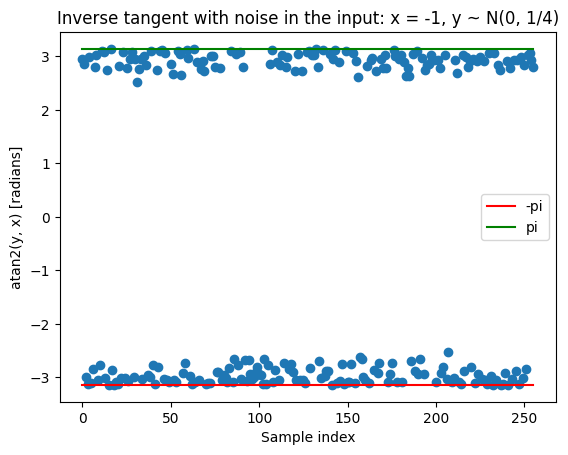

In [37]:
n = 256
x = -1 * np.ones(n)
y = stats.norm.rvs(loc=0, scale=1 / 4, size=n)
plt.plot(np.atan2(y, x), "o")
plt.plot(-np.pi * np.ones(n), "r", label="-pi")
plt.plot(np.pi * np.ones(n), "g", label="pi")
plt.title("Inverse tangent with noise in the input: x = -1, y ~ N(0, 1/4)")
plt.xlabel("Sample index")
plt.ylabel("atan2(y, x) [radians]")
plt.legend()
plt.show()

## Angles estimation from accelerometer data

### Correct angle decision

The accelerometer-based pitch formula has `sqrt(ay^2 + az^2)` in the denominator. The square root is always non-negative, so this principal solution is limited to the interval [-90°, 90°]. That is not a bug in `atan2`. It reflects a real ambiguity in the Euler-angle decomposition of gravity.

To keep the complementary filter on the physically consistent branch, the notebook computes the principal accelerometer solution together with its equivalent upside-down branch. The filter then uses the gyroscope prediction to decide which branch is closer to the recent motion before applying the accelerometer correction.

This approach improves branch selection, but it does not remove the limitations of Euler angles near pitch = ±90°. In that region the mapping becomes ill-conditioned, so small sensor noise can produce large roll/pitch changes. This is closely related to gimbal lock, where two rotation axes become aligned and Euler angles a degree of freedom.

### Noise tolerance

The acceleration tolerance for the modified inverse tangent can't be larger than 0.1-0.2 m/s2. Otherwise it starts to filter out real, human scale motions, like the initial phase of a walk, a gentle motion of a vehicle, etc. Remember than the tolerance value depends on the chosen alpha for the complementary filter: the lower the alpha, the lower the tolerance should be, as the accelerometer contribution is larger.


In [38]:
accelTol = 0.125
modAtan2 = lambda y, x: math.atan2(y, x) if abs(y) > accelTol else math.atan2(0, x)
wrapDeg = lambda angle: (angle + 180.0) % 360.0 - 180.0
angleDistanceDeg = lambda a, b: abs(wrapDeg(a - b))


def computeAccelAngleCandidates(ax, ay, az):
    rollPrincipal = 180 / np.pi * modAtan2(ay, az)
    pitchPrincipal = 180 / np.pi * modAtan2(-ax, math.sqrt(ay**2 + az**2))

    rollAlternative = wrapDeg(rollPrincipal + 180.0)
    pitchAlternative = math.copysign(180.0 - abs(pitchPrincipal), pitchPrincipal)

    return (rollPrincipal, pitchPrincipal), (rollAlternative, pitchAlternative)


rollAngleAccel = np.zeros(len(samples["a"]["x"]))  # type: ignore
pitchAngleAccel = np.zeros(len(samples["a"]["x"]))  # type: ignore
for i, (ax, ay, az) in enumerate(zip(samples["a"]["x"], samples["a"]["y"], samples["a"]["z"])):  # type: ignore
    (rollPrincipal, pitchPrincipal), _ = computeAccelAngleCandidates(ax, ay, az)
    rollAngleAccel[i] = rollPrincipal
    pitchAngleAccel[i] = pitchPrincipal

## Angles estimation from gyroscope data

In [39]:
SAMPLING_FREQUENCY = 30  # Hz
dt = 1 / SAMPLING_FREQUENCY

integrateEuler = lambda prev, slope, step: prev + slope * step

signalLength = len(samples["w"]["roll"])  # type: ignore
rollAngleGyro = np.zeros(signalLength)  # type: ignore
pitchAngleGyro = np.zeros(signalLength)  # type: ignore
yawAngleGyro = np.zeros(signalLength)  # type: ignore
for i in range(1, signalLength):  # type: ignore
    rollAngleGyro[i] = integrateEuler(rollAngleGyro[i - 1], samples["w"]["roll"][i], dt)  # type: ignore
    pitchAngleGyro[i] = integrateEuler(pitchAngleGyro[i - 1], samples["w"]["pitch"][i], dt)  # type: ignore
    yawAngleGyro[i] = integrateEuler(yawAngleGyro[i - 1], samples["w"]["yaw"][i], dt)  # type: ignore

## Estimation of movement detection tolerance

In [40]:
calibratedStationaryCapturesPaths = [
    "../1-calibration/output/positive-x-up-calibrated.csv",
    "../1-calibration/output/negative-x-up-calibrated.csv",
    "../1-calibration/output/positive-y-up-calibrated.csv",
    "../1-calibration/output/negative-y-up-calibrated.csv",
    "../1-calibration/output/positive-z-up-calibrated.csv",
    "../1-calibration/output/negative-z-up-calibrated.csv",
]
accelNorms = np.array([])
for path in calibratedStationaryCapturesPaths:
    stationarySamples = reader.read(path)
    ax = np.array(stationarySamples["a"]["x"])
    ay = np.array(stationarySamples["a"]["y"])
    az = np.array(stationarySamples["a"]["z"])
    accelNorms = np.append(accelNorms, np.sqrt(ax**2 + ay**2 + az**2))
accelNormsMean = fmean(accelNorms)
accelNormsStdev = pstdev(accelNorms)
movementTol = 1.5 * accelNormsStdev
print(
    f"Accel norms: mean={accelNormsMean:.6f}, stdev={accelNormsStdev:.6f}\nStationary tol = {movementTol:.6f}"
)

Accel norms: mean=9.806204, stdev=0.040047
Stationary tol = 0.060070


## Complementary filter

The gyroscope is first integrated to predict the next roll and pitch angles. For each accelerometer sample, the notebook evaluates the principal Euler solution and its alternative branch, then computes a wrapped angular error against the gyroscope prediction. The branch with the lower aggregate roll/pitch error is used as the accelerometer correction.

This is a local continuity heuristic rather than an exact distance on the full 3D rotation space, but it is a minimal way to keep the filter from snapping to the wrong pitch branch when the motion crosses ±90°. Near that region the estimate can still become noisy because Euler angles are close to their singular configuration.

In [41]:
g = 9.81
alpha = 0.9
rollAngleCompl = np.zeros(signalLength)  # type: ignore
pitchAngleCompl = np.zeros(signalLength)  # type: ignore
rollAngleAccelResolved = np.zeros(signalLength)  # type: ignore
pitchAngleAccelResolved = np.zeros(signalLength)  # type: ignore
rollAngleAccelResolved[0] = rollAngleAccel[0]
pitchAngleAccelResolved[0] = pitchAngleAccel[0]
for i in range(1, signalLength):  # type: ignore
    ax = samples["a"]["x"][i]  # type: ignore
    ay = samples["a"]["y"][i]  # type: ignore
    az = samples["a"]["z"][i]  # type: ignore
    rollPred = rollAngleCompl[i - 1] + samples["w"]["roll"][i] * dt  # type: ignore
    pitchPred = pitchAngleCompl[i - 1] + samples["w"]["pitch"][i] * dt  # type: ignore

    (rollPrincipal, pitchPrincipal), (rollAlternative, pitchAlternative) = (
        computeAccelAngleCandidates(ax, ay, az)
    )
    principalError = angleDistanceDeg(rollPrincipal, rollPred) + angleDistanceDeg(
        pitchPrincipal, pitchPred
    )
    alternativeError = angleDistanceDeg(rollAlternative, rollPred) + angleDistanceDeg(
        pitchAlternative, pitchPred
    )

    if principalError <= alternativeError:
        rollAccResolved = rollPrincipal
        pitchAccResolved = pitchPrincipal
    else:
        rollAccResolved = rollAlternative
        pitchAccResolved = pitchAlternative

    rollAngleAccelResolved[i] = rollAccResolved
    pitchAngleAccelResolved[i] = pitchAccResolved

    rollAccContinuous = rollPred + wrapDeg(rollAccResolved - rollPred)
    pitchAccContinuous = pitchPred + wrapDeg(pitchAccResolved - pitchPred)

    if abs(math.sqrt(ax**2 + ay**2 + az**2) - g) < movementTol:
        rollAngleCompl[i] = alpha * rollPred + (1 - alpha) * rollAccContinuous
        pitchAngleCompl[i] = alpha * pitchPred + (1 - alpha) * pitchAccContinuous
    else:
        rollAngleCompl[i] = rollPred
        pitchAngleCompl[i] = pitchPred

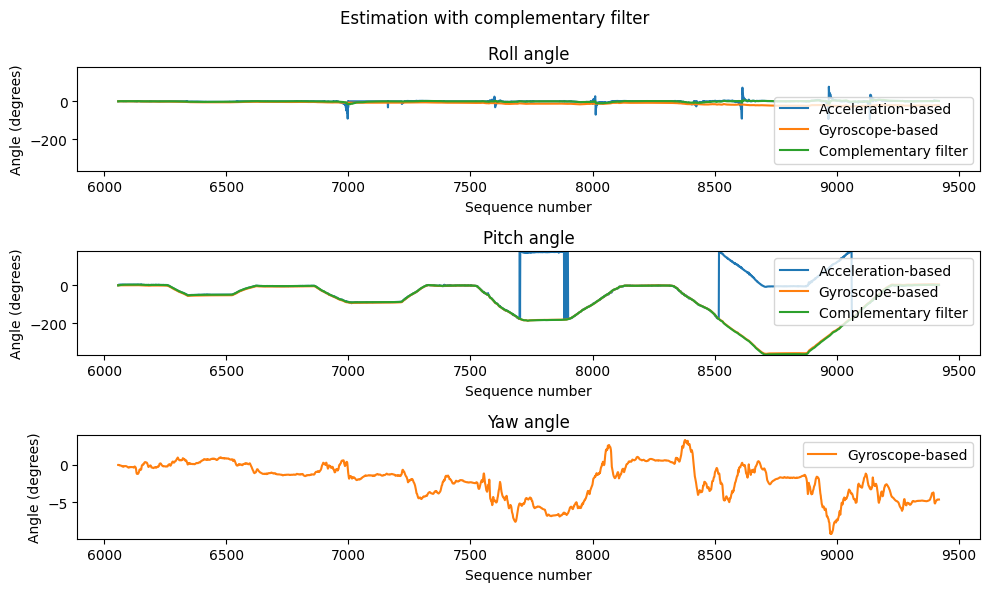

In [42]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6))

fig.suptitle("Estimation with complementary filter")

lowerBoundAngle = min(min(rollAngleAccelResolved), min(pitchAngleAccelResolved), min(rollAngleGyro), min(pitchAngleGyro), min(yawAngleGyro), min(rollAngleCompl), min(pitchAngleCompl))  # type: ignore
upperBoundAngle = max(max(rollAngleAccelResolved), max(pitchAngleAccelResolved), max(rollAngleGyro), max(pitchAngleGyro), max(yawAngleGyro), max(rollAngleCompl), max(pitchAngleCompl))  # type: ignore

axes[0].plot(samples["seq"], rollAngleAccelResolved, label="Acceleration-based")
axes[0].plot(samples["seq"], rollAngleGyro, label="Gyroscope-based")
axes[0].plot(samples["seq"], rollAngleCompl, label="Complementary filter")
axes[0].set_ylabel("Angle (degrees)")
axes[0].set_ylim(lowerBoundAngle, upperBoundAngle)
axes[0].set_xlabel("Sequence number")
axes[0].set_title("Roll angle")
axes[0].legend()

axes[1].plot(samples["seq"], pitchAngleAccelResolved, label="Acceleration-based")
axes[1].plot(samples["seq"], pitchAngleGyro, label="Gyroscope-based")
axes[1].plot(samples["seq"], pitchAngleCompl, label="Complementary filter")
axes[1].set_ylabel("Angle (degrees)")
axes[1].set_ylim(lowerBoundAngle, upperBoundAngle)
axes[1].set_xlabel("Sequence number")
axes[1].set_title("Pitch angle")
axes[1].legend()

axes[2].plot(samples["seq"], yawAngleGyro, label="Gyroscope-based", color="#ff7f0e")
axes[2].set_ylabel("Angle (degrees)")
axes[2].set_xlabel("Sequence number")
axes[2].set_title("Yaw angle")
axes[2].legend()

plt.tight_layout()
plt.show()